In [1]:
import os
import numpy as np
import pandas as pd
import cv2
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt

# -------------------------
# 1) Lire le CSV
# -------------------------
csv_path = "../data/dataset_selection_sans_leger.csv"
df = pd.read_csv(csv_path)
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)
df["exists"] = df["path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"[WARN] {missing} fichiers manquants — supprimés.")
df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)

le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["y"])
test_df, val_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["y"])
print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 4966 | Val : 621 | Test : 621


In [2]:
# -------------------------
# 2) Preprocessing : crop + CLAHE
# CLAHE = contraste adaptatif local, très utilisé en rétinographie
# -------------------------

def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    arr = np.array(img)
    gray = arr.mean(axis=2)
    mask = gray > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    y0 = max(0, y0 - pad); x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)
    return img.crop((x0, y0, x1 + 1, y1 + 1))

def apply_clahe(img: Image.Image, clip_limit=2.0, tile_grid=(8, 8)):
    """Applique CLAHE sur le canal L de l'espace LAB."""
    arr = np.array(img)
    lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l = clahe.apply(l)
    lab = cv2.merge([l, a, b])
    result = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return Image.fromarray(result)

In [3]:
# -------------------------
# 3) Dataset avec CLAHE
# -------------------------
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, shear=5, scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Augmentations pour TTA (inférence)
tta_tfms_list = [
    val_tfms,  # original
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(10, 10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(-10, -10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
]

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True, do_clahe=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop
        self.do_clahe = do_clahe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.do_crop:
            img = crop_black_border_pil(img)
        if self.do_clahe:
            img = apply_clahe(img)
        if self.transform:
            img = self.transform(img)
        return img, int(row["y"])

train_ds = FundusDataset(train_df, transform=train_tfms)
val_ds   = FundusDataset(val_df,   transform=val_tfms)
test_ds  = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [4]:
# -------------------------
# 4) Modèle DenseNet-121
# Label smoothing = 0.1 pour réduire l'overconfidence
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model = model.to(device)

# Label smoothing : réduit l'overconfidence (train acc montait à 99% alors que val stagnait)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

Device: cuda


In [5]:
# -------------------------
# 5) Fonctions train / eval
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            running_loss += criterion(logits, y).item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return running_loss / total, correct / total

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

def run_training(model, train_loader, val_loader, optimizer, scheduler,
                 epochs=200, patience=11, save_path="best.pth", label=""):
    best_val_acc = 0.0
    epochs_no_improve = 0
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc = evaluate(model, val_loader)
        scheduler.step(va_acc)
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
        lr = optimizer.param_groups[0]["lr"]
        print(f"{label} Epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f} | lr {lr:.2e}")
        if epochs_no_improve >= patience:
            print(f"Early stopping epoch {epoch}")
            break
    print(f"Meilleure val acc : {best_val_acc:.4f}")
    return best_val_acc

In [6]:
# -------------------------
# 6) Phase 1 : backbone gelé, entraîner seulement le classifier
# Convergence rapide, évite de détruire les features pré-entraînées
# -------------------------
print("=== PHASE 1 : backbone gelé ===")

for name, param in model.named_parameters():
    param.requires_grad = "classifier" in name

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler_p1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_p1, mode="max", patience=2, factor=0.5)

run_training(model, train_loader, val_loader, optimizer_p1, scheduler_p1,
             epochs=10, patience=5, save_path="test_phase1.pth", label="[P1]")

=== PHASE 1 : backbone gelé ===
[P1] Epoch 01 | train 0.9764/0.6522 | val 0.9150/0.6651 | lr 1.00e-03
[P1] Epoch 02 | train 0.8517/0.7354 | val 0.8866/0.7037 | lr 1.00e-03
[P1] Epoch 03 | train 0.8182/0.7493 | val 0.8181/0.7617 | lr 1.00e-03
[P1] Epoch 04 | train 0.7990/0.7582 | val 0.8581/0.7037 | lr 1.00e-03
[P1] Epoch 05 | train 0.7852/0.7676 | val 0.8005/0.7649 | lr 1.00e-03
[P1] Epoch 06 | train 0.7833/0.7759 | val 0.8243/0.7262 | lr 1.00e-03
[P1] Epoch 07 | train 0.7760/0.7791 | val 0.7980/0.7665 | lr 1.00e-03
[P1] Epoch 08 | train 0.7726/0.7759 | val 0.8088/0.7585 | lr 1.00e-03
[P1] Epoch 09 | train 0.7686/0.7795 | val 0.8299/0.7440 | lr 1.00e-03
[P1] Epoch 10 | train 0.7734/0.7759 | val 0.8175/0.7504 | lr 5.00e-04
Meilleure val acc : 0.7665


0.7665056360708534

In [7]:
# -------------------------
# 7) Phase 2 : dégeler tout avec lr différencié
# Backbone : lr très faible pour ne pas écraser les features
# Classifier : lr plus élevé car initialisé aléatoirement
# -------------------------
print("=== PHASE 2 : fine-tuning complet ===")

for param in model.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.AdamW([
    {"params": [p for n, p in model.named_parameters() if "classifier" not in n], "lr": 1e-5},
    {"params": model.classifier.parameters(), "lr": 1e-4},
], weight_decay=1e-4)

scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_p2, mode="max", patience=3, factor=0.5)

run_training(model, train_loader, val_loader, optimizer_p2, scheduler_p2,
             epochs=200, patience=11, save_path="test_densenet_improved.pth", label="[P2]")

=== PHASE 2 : fine-tuning complet ===
[P2] Epoch 01 | train 0.7287/0.8031 | val 0.7498/0.8019 | lr 1.00e-05
[P2] Epoch 02 | train 0.6890/0.8306 | val 0.7458/0.7923 | lr 1.00e-05
[P2] Epoch 03 | train 0.6651/0.8429 | val 0.6992/0.8180 | lr 1.00e-05
[P2] Epoch 04 | train 0.6433/0.8548 | val 0.6700/0.8357 | lr 1.00e-05
[P2] Epoch 05 | train 0.6300/0.8641 | val 0.6466/0.8535 | lr 1.00e-05
[P2] Epoch 06 | train 0.6155/0.8711 | val 0.6464/0.8567 | lr 1.00e-05
[P2] Epoch 07 | train 0.6000/0.8830 | val 0.6425/0.8615 | lr 1.00e-05
[P2] Epoch 08 | train 0.5836/0.8888 | val 0.6368/0.8712 | lr 1.00e-05
[P2] Epoch 09 | train 0.5808/0.8927 | val 0.6295/0.8696 | lr 1.00e-05
[P2] Epoch 10 | train 0.5601/0.9025 | val 0.6197/0.8663 | lr 1.00e-05
[P2] Epoch 11 | train 0.5573/0.9048 | val 0.6169/0.8712 | lr 1.00e-05
[P2] Epoch 12 | train 0.5463/0.9142 | val 0.6104/0.8824 | lr 1.00e-05
[P2] Epoch 13 | train 0.5397/0.9148 | val 0.6063/0.8824 | lr 1.00e-05
[P2] Epoch 14 | train 0.5338/0.9235 | val 0.5998/0.8

0.9082125603864735

In [8]:
# -------------------------
# 8) TTA — Test Time Augmentation
# Moyenne des probas sur 5 versions augmentées de chaque image
# -------------------------
def predict_with_tta(model, df_test, tta_tfms_list, device, do_clahe=True):
    model.eval()
    all_probas = []
    y_true_all = None

    for t_idx, tfm in enumerate(tta_tfms_list):
        ds = FundusDataset(df_test, transform=tfm, do_crop=True, do_clahe=do_clahe)
        loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
        probas, y_true = [], []
        with torch.no_grad():
            for x, y in loader:
                x = x.to(device, non_blocking=True)
                probs = torch.softmax(model(x), dim=1).cpu().numpy()
                probas.append(probs)
                y_true.append(y.numpy())
        all_probas.append(np.concatenate(probas))
        if y_true_all is None:
            y_true_all = np.concatenate(y_true)
        print(f"TTA {t_idx+1}/{len(tta_tfms_list)} done")

    avg_probas = np.mean(all_probas, axis=0)
    y_pred = avg_probas.argmax(axis=1)
    return y_true_all, y_pred, avg_probas

# Charger le meilleur modèle DenseNet amélioré
model.load_state_dict(torch.load("test_densenet_improved.pth", map_location=device))

print("--- TTA sur DenseNet amélioré ---")
y_true_tta, y_pred_tta, proba_tta = predict_with_tta(model, test_df, tta_tfms_list, device)

print("\n=== Classification report — DenseNet + CLAHE + 2-phase + TTA ===")
print(classification_report(y_true_tta, y_pred_tta, target_names=le.classes_, digits=4))

/tmp/ipykernel_218605/2137002152.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("test_densenet_improved.pth", map_location=device))


--- TTA sur DenseNet amélioré ---
TTA 1/5 done
TTA 2/5 done
TTA 3/5 done
TTA 4/5 done
TTA 5/5 done

=== Classification report — DenseNet + CLAHE + 2-phase + TTA ===
              precision    recall  f1-score   support

     diabete     0.9333    0.9032    0.9180       155
    glaucome     0.9202    0.9677    0.9434       155
         mda     0.8862    0.9487    0.9164       156
     normaux     0.8440    0.7677    0.8041       155

    accuracy                         0.8969       621
   macro avg     0.8959    0.8969    0.8955       621
weighted avg     0.8959    0.8969    0.8955       621



In [9]:
# -------------------------
# 9) Ensemble DenseNet amélioré + EfficientNet-B3
# Moyenne des probas des deux modèles
# -------------------------

# Charger EfficientNet-B3 sauvegardé
model_eff = models.efficientnet_b3(weights=None)
model_eff.classifier[1] = nn.Linear(model_eff.classifier[1].in_features, num_classes)
model_eff.load_state_dict(torch.load("efficientnet/efficientnet_b3_best.pth", map_location=device))
model_eff = model_eff.to(device)
model_eff.eval()
print("EfficientNet-B3 chargé.")

# TTA pour EfficientNet (résolution 300)
eff_tfms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def predict_single(model, df_test, tfm, device, do_clahe=True):
    model.eval()
    ds = FundusDataset(df_test, transform=tfm, do_crop=True, do_clahe=do_clahe)
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
    probas, y_true = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            probs = torch.softmax(model(x), dim=1).cpu().numpy()
            probas.append(probs)
            y_true.append(y.numpy())
    return np.concatenate(y_true), np.concatenate(probas)

y_true_eff, proba_eff = predict_single(model_eff, test_df, eff_tfms, device)

# Ensemble : moyenne simple des probas
proba_ensemble = (proba_tta + proba_eff) / 2
y_pred_ensemble = proba_ensemble.argmax(axis=1)

print("\n=== Classification report — Ensemble DenseNet + EfficientNet ===")
print(classification_report(y_true_eff, y_pred_ensemble, target_names=le.classes_, digits=4))

try:
    auc = roc_auc_score(y_true_eff, proba_ensemble, multi_class="ovr", average="macro")
    print(f"AUC-ROC macro (OvR) : {auc:.4f}")
except Exception as e:
    print(f"AUC-ROC non calculable : {e}")

/tmp/ipykernel_218605/2056386078.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_eff.load_state_dict(torch.load("efficientnet/efficientnet_b3_best.pth", map_locati

EfficientNet-B3 chargé.

=== Classification report — Ensemble DenseNet + EfficientNet ===
              precision    recall  f1-score   support

     diabete     0.9574    0.8710    0.9122       155
    glaucome     0.9317    0.9677    0.9494       155
         mda     0.8743    0.9359    0.9040       156
     normaux     0.8092    0.7935    0.8013       155

    accuracy                         0.8921       621
   macro avg     0.8931    0.8920    0.8917       621
weighted avg     0.8931    0.8921    0.8917       621

AUC-ROC macro (OvR) : 0.9805


In [10]:
# -------------------------
# 10) Résumé comparatif
# -------------------------
from sklearn.metrics import accuracy_score

# Récupérer les probas du DenseNet original (sans améliorations) pour comparaison
model_baseline = models.densenet121(weights=None)
model_baseline.classifier = nn.Linear(model_baseline.classifier.in_features, num_classes)
model_baseline.load_state_dict(torch.load("densenet/densenet121_best.pth", map_location=device))
model_baseline = model_baseline.to(device)

y_true_base, proba_base = predict_single(model_baseline, test_df, val_tfms, device)
y_pred_base = proba_base.argmax(axis=1)

print("=" * 50)
print(f"DenseNet-121 baseline         : {accuracy_score(y_true_base, y_pred_base):.4f}  (référence : 0.9340)")
print(f"DenseNet + CLAHE + 2phase + TTA : {accuracy_score(y_true_tta, y_pred_tta):.4f}")
print(f"Ensemble DenseNet + EfficientNet: {accuracy_score(y_true_eff, y_pred_ensemble):.4f}")
print("=" * 50)

/tmp/ipykernel_218605/3446908973.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_baseline.load_state_dict(torch.load("densenet/densenet121_best.pth", map_location=

DenseNet-121 baseline         : 0.8712  (référence : 0.9340)
DenseNet + CLAHE + 2phase + TTA : 0.8969
Ensemble DenseNet + EfficientNet: 0.8921


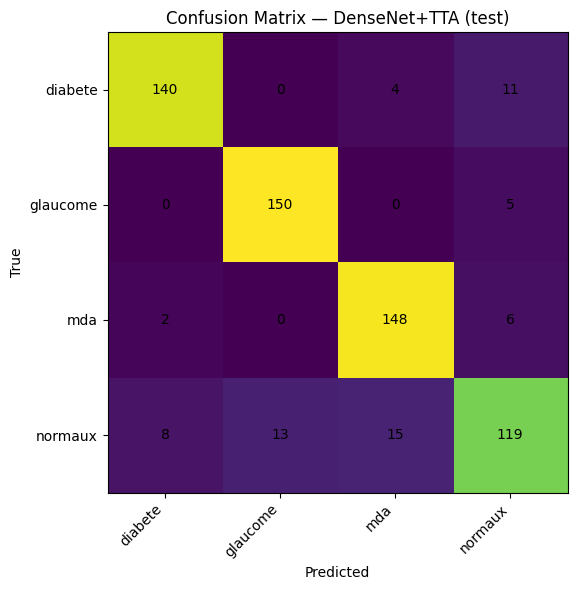

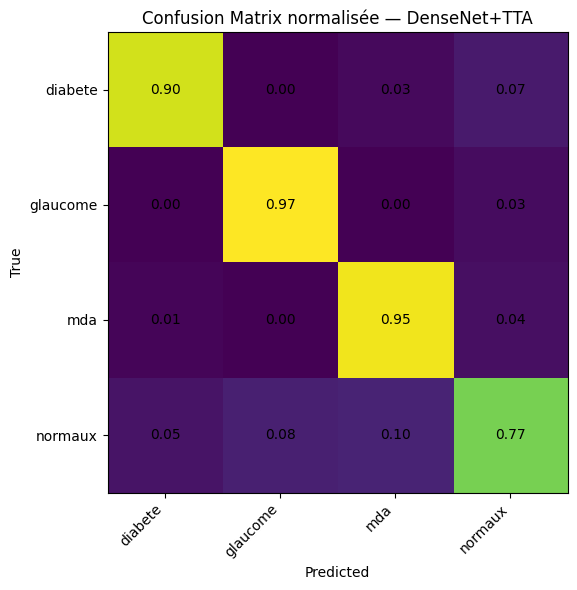

In [11]:
# -------------------------
# 11) Matrice de confusion du meilleur résultat
# -------------------------
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(cm)
    ax.set_xticks(np.arange(len(class_names))); ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm[i,j]:.2f}" if normalize else str(cm[i,j]), ha="center", va="center")
    plt.tight_layout(); plt.show()

# Prendre le meilleur entre TTA seul et ensemble
best_pred = y_pred_ensemble if accuracy_score(y_true_eff, y_pred_ensemble) > accuracy_score(y_true_tta, y_pred_tta) else y_pred_tta
best_true = y_true_eff
best_title = "Ensemble" if accuracy_score(y_true_eff, y_pred_ensemble) > accuracy_score(y_true_tta, y_pred_tta) else "DenseNet+TTA"

cm = confusion_matrix(best_true, best_pred)
plot_confusion_matrix(cm, list(le.classes_), title=f"Confusion Matrix — {best_title} (test)")
plot_confusion_matrix(cm, list(le.classes_), title=f"Confusion Matrix normalisée — {best_title}", normalize=True)